# Binary distillation column: the infinite horizon on a full DAE

The model is the declared binary column from
[`models/binary_column.py`](models/binary_column.py): 42 trays,
methanol/n-propanol (the Diehl 2001 lineage), translated faithfully from the
Dinh et al. code. Tray holdup and liquid composition are states; temperature,
vapor composition, vapor flow, liquid flow, volume holdup, and condenser duty
are algebraic. The tray energy balance keeps its index-reduced form and
references dx/dt directly, which the terminal segment handles by dilating the
derivative references along with the dynamics.

Two cases of the same model, driving the transition from the initial steady
state (Qr = 1.5, Rec = 10) to the reference (Qr = 1.65, Rec = 1). Case 1
runs five sampling steps with the infinite-horizon terminal segment
(`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs the full twenty-step finite horizon with the
terminal cost live.

Both cases initialize before the solve (`initialize.py`): the states
interpolate linearly from the initial condition to the steady state, the
derivatives take the interpolation slope, and the algebraic and cost
variables then come from their defining equations. A stand-in until
initialization lands in drto.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.binary_column import binary_column
from plotting import plot_states, plot_controls, plot_stage_cost
from initialize import initialize_binary_column

m1 = binary_column(N=5, h=60)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
initialize_binary_column(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)

WARNING (W1002): Setting Var 'drto_infinite_horizon.Mv[1,0]' to a numeric
value `1.0` outside the bounds (8.500001, 10000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002


WARNING (W1002): Setting Var 'drto_infinite_horizon.Mv[1,0.015637]' to a
numeric value `1.0` outside the bounds (8.500001, 10000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002


WARNING (W1002): Setting Var 'drto_infinite_horizon.Mv[1,0.076922]' to a
numeric value `1.0` outside the bounds (8.500001, 10000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002


WARNING (W1002): Setting Var 'drto_infinite_horizon.Mv[1,0.166666]' to a
numeric value `1.0` outside the bounds (8.500001, 10000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002


WARNING (W1002): Setting Var 'drto_infinite_horizon.Mv[1,0.256411]' to a
numeric value `1.0` outside the bounds (8.500001, 10000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002


...

 314  1.2989012e+03 4.00e-07 5.26e-06   -5.7 5.29e+00      - 1.00e+00 1.00e+00h  1


 315  1.2989012e+03 4.33e-09 8.20e-08   -8.6 5.56e-01      - 1.00e+00 1.00e+00h  1


pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmp5bthk06p.pyomo.sol


 316  1.2989012e+03 2.28e-09 1.17e-11   -8.6 6.68e-04      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 316

                                   (scaled)                 (unscaled)
Objective...............:   1.2989011889487488e+03    1.2989011889487488e+03
Dual infeasibility......:   1.1676330727511346e-11    1.1676330727511346e-11
Constraint violation....:   2.2755557438358665e-09    2.2755557438358665e-09
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5061792532108354e-09    2.5061792532108354e-09
Overall NLP error.......:   2.5061792532108354e-09    2.5061792532108354e-09


Number of objective function evaluations             = 724
Number of objective gradient evaluations             = 300
Number of equality constraint evaluations            = 724
Number of inequality constraint evaluations          = 724
Number of equality constraint Jacobian evaluations   = 319
Number of inequality constraint Jacobian evaluations =

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 13338, 'Number of variables': 13370, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 247.91202545166016}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

horizon,"t (ContinuousSet, 16 points)"
states,"M (free), x (free)"
dynamics,"dM[k,t] == L[2,t] - L[k,t] - V[k,t] for k in tray, t in t"
dynamics,"dx[k,t] == (L[2,t]*(x[2,t] - x[k,t]) - V[k,t]*(y[k,t] - x[k,t]))/M[k,t] for k in tray, t in t"
controls,"Rec (piecewise_constant, free), Qr (piecewise_constant, free)"
tracking stage cost,"cost[t] == (Rec[t] - Rec_ss)**2 + (Qr[t] - Qr_ss)**2 + 10*SUM((x[i,t] - x_ss[i])**2 + ((M[i,t] - M_ss[i])/M_ss[i])**2 for i in tray) for t in sorted(t)[:-1]"
terminal cost,"term == 10*SUM((x[i,300] - x_ss[i])**2 + ((M[i,300] - M_ss[i])/M_ss[i])**2 for i in tray)"
initial conditions,"M_hat[k] == M[k,0] for k in tray"
initial conditions,"x_hat[k] == x[k,0] for k in tray"
steady-state targets,"M_ss (of M), x_ss (of x)"
steady-state control targets,"Rec_ss (of Rec), Qr_ss (of Qr)"


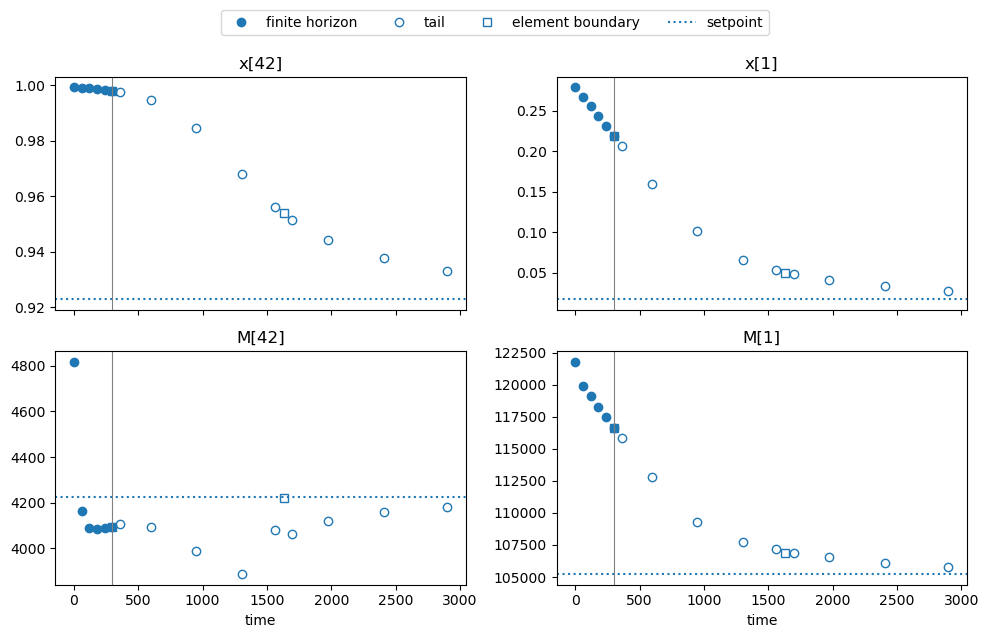

In [3]:
# multi-index states select by member: top and bottoms compositions, drum holdups
plot_states(m1, states=["x[42]", "x[1]", "M[42]", "M[1]"], t_max=3000);

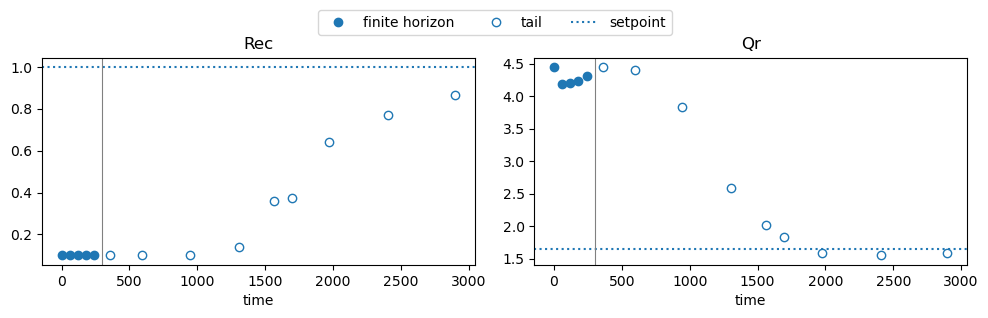

In [4]:
plot_controls(m1, t_max=3000);

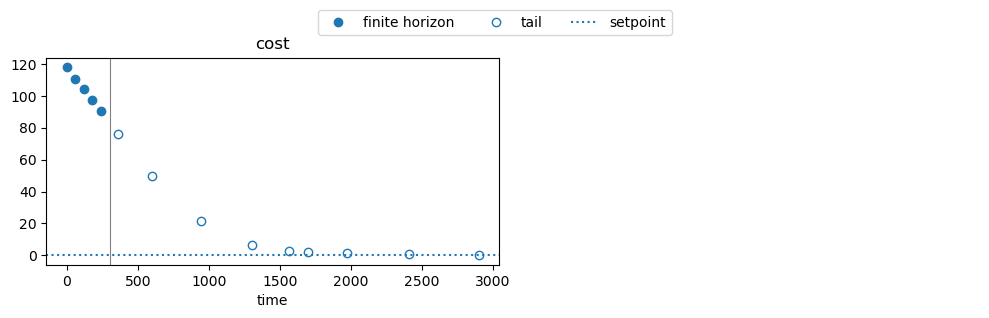

In [5]:
plot_stage_cost(m1, t_max=3000);

## Case 2: twenty samples, finite horizon with the terminal cost

In [6]:
m2 = binary_column(N=20, h=60)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=20, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
initialize_binary_column(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmprmgod39a.pyomo.nl...


Parsed 25620 vars, 25580 cons, jac_nnz=141240, h_nnz=69303 in 1.78s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:   141240
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    69303

Total number of variables............................:    25620
                     variables with only lower bounds:       20
                variables with lower and upper bounds:    13651
                     variables with only upper bounds:        0
Total number of equality constraints.................:    25580
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0



iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  7.8603088e+02 4.40e+01 1.02e-01   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0


   1  1.1626655e+03 2.80e+01 4.16e+03   -1.0 1.59e+04      - 6.64e-02 5.93e-01h  1


   2  1.4480880e+03 2.08e+01 2.66e+03   -1.0 9.39e+03      - 4.82e-01 3.33e-01h  1


...

  36  1.1462651e+03 1.61e-05 4.84e-06   -5.7 3.66e-01      - 1.00e+00 1.00e+00h  1


  37  1.1462650e+03 4.32e-07 1.19e-07   -8.6 6.59e-02      - 1.00e+00 1.00e+00h  1


  38  1.1462650e+03 3.23e-12 7.28e-12   -8.6 3.80e-05      - 1.00e+00 1.00e+00h  1
pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmprmgod39a.pyomo.sol




Number of Iterations....: 38

                                   (scaled)                 (unscaled)
Objective...............:   1.1462650241566328e+03    1.1462650241566328e+03
Dual infeasibility......:   7.2759576141834259e-12    7.2759576141834259e-12
Constraint violation....:   3.2276403771902551e-12    3.2276403771902551e-12
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059740245153803e-09    2.5059740245153803e-09
Overall NLP error.......:   2.5059740245153803e-09    2.5059740245153803e-09


Number of objective function evaluations             = 40
Number of objective gradient evaluations             = 40
Number of equality constraint evaluations            = 40
Number of inequality constraint evaluations          = 40
Number of equality constraint Jacobian evaluations   = 40
Number of inequality constraint Jacobian evaluations = 40
Number of Lagrangian Hessian evaluations             = 39
Total seconds in POUNCE    

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 25580, 'Number of variables': 25620, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 35.59937405586243}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [7]:
drto.info(m2)

horizon,"t (ContinuousSet, 61 points)"
states,"M (free), x (free)"
dynamics,"dM[k,t] == L[2,t] - L[k,t] - V[k,t] for k in tray, t in t"
dynamics,"dx[k,t] == (L[2,t]*(x[2,t] - x[k,t]) - V[k,t]*(y[k,t] - x[k,t]))/M[k,t] for k in tray, t in t"
controls,"Rec (piecewise_constant, free), Qr (piecewise_constant, free)"
tracking stage cost,"cost[t] == (Rec[t] - Rec_ss)**2 + (Qr[t] - Qr_ss)**2 + 10*SUM((x[i,t] - x_ss[i])**2 + ((M[i,t] - M_ss[i])/M_ss[i])**2 for i in tray) for t in sorted(t)[:-1]"
terminal cost,"term == 10*SUM((x[i,1200] - x_ss[i])**2 + ((M[i,1200] - M_ss[i])/M_ss[i])**2 for i in tray)"
initial conditions,"M_hat[k] == M[k,0] for k in tray"
initial conditions,"x_hat[k] == x[k,0] for k in tray"
steady-state targets,"M_ss (of M), x_ss (of x)"
steady-state control targets,"Rec_ss (of Rec), Qr_ss (of Qr)"


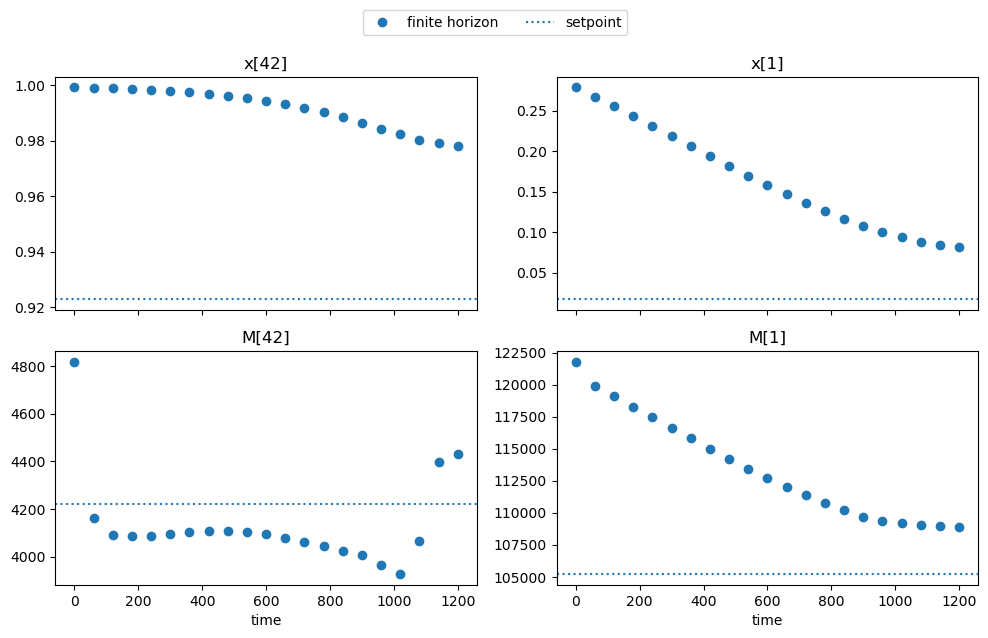

In [8]:
plot_states(m2, states=["x[42]", "x[1]", "M[42]", "M[1]"], t_max=3000);

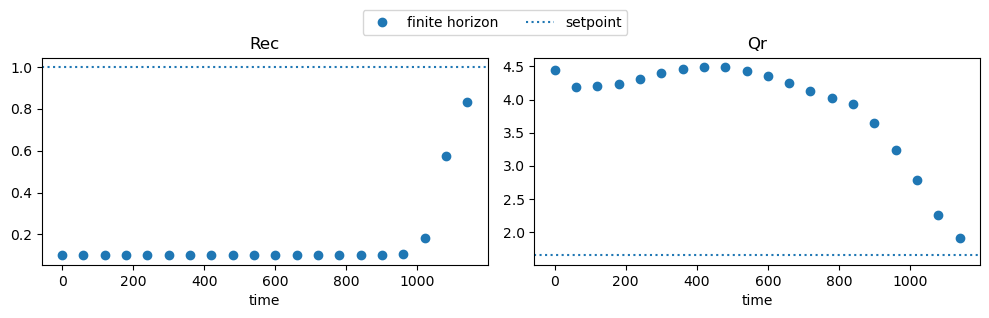

In [9]:
plot_controls(m2, t_max=3000);

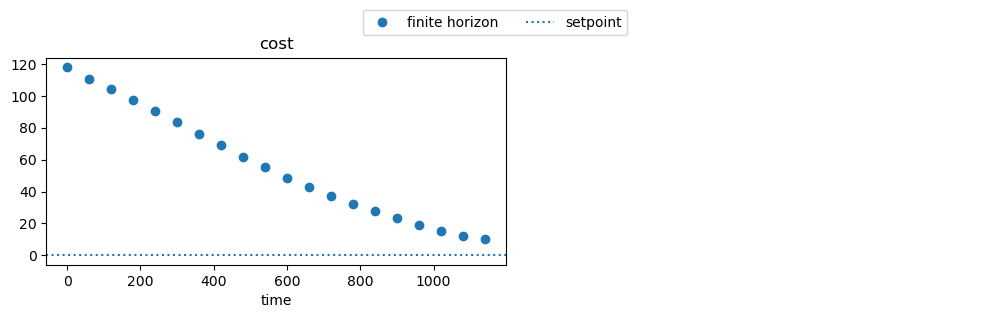

In [10]:
plot_stage_cost(m2, t_max=3000);